# 2. Heat Equation with a Static Random Potential

In Notebook 1, we developed an explicit Euler solver for the one-dimensional heat equation. In this notebook, we extend that framework by introducing a static random potential, leading to the one-dimensional parabolic Anderson model (PAM).

Using the same numerical discretization, we investigate how the random potential influences the evolution of the solution and gives rise to localization.

## Objectives

In this notebook we will

- introduce the one-dimensional parabolic Anderson model,
- derive its explicit Euler discretization,
- implement a reusable numerical solver,
- investigate the influence of a static random potential, and
- illustrate localization through numerical experiments.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Mathematical Background
### The Parabolic Anderson Model

The one-dimensional parabolic Anderson model is obtained by augmenting the heat equation with a spatially varying potential,

$$
\frac{\partial u}{\partial t}
=
\kappa
\frac{\partial^2u}{\partial x^2}
+
\lambda\xi(x)u,
\qquad
x\in[0,1],\; t>0.
$$


Here, $\kappa>0$ is the diffusion coefficient, $\xi(x)$ is a random field that is sampled once and held fixed throughout the simulation, and $\lambda \neq 0$ is a constant that controls the strength of the random potential.

As in Notebook 1, we impose periodic boundary conditions together with the initial condition

$$
u(x,0)=u_0(x).
$$

In [2]:
def laplacian(u, h):
    """Compute the one-dimensional periodic discrete Laplacian."""
    return (np.roll(u, -1) - 2 * u + np.roll(u, 1)) / h**2

In [3]:
# Heat equation solver introduced in Notebook 1.
# Included here so this notebook can be run independently.

def solve_heat_equation(u0, h, dt, num_steps, kappa=0.5):
    """
    Solve the one-dimensional heat equation
    using the explicit Euler method.
    """
    u = u0.copy()

    for _ in range(num_steps):
        u += kappa * dt * laplacian(u, h)

    return u

## Numerical Method
### Explicit Euler Discretization

We discretize the spatial domain using the same uniform grid introduced in Notebook 1. The second derivative is approximated by the centered finite difference operator,

$$
\Delta_hu_i
=
\frac{u_{i+1}-2u_i+u_{i-1}}{h^2}.
$$

Applying the explicit Euler method in time gives


$$
u_i^{n+1}
=
u_i^n
+
\Delta t
\left(
\kappa\Delta_hu_i^n
+
\lambda\xi_i u_i^n
\right).
$$

where $\xi_i=\xi(x_i)$ denotes the sampled potential at the grid point $x_i$. Compared with the heat equation, the only modification is the additional reaction term.

## Numerical Experiments
### Simulation Parameters

We use the same computational grid and Gaussian initial condition as in Notebook 1. This provides a baseline before introducing randomness into the equation. For the numerical experiments, we choose a larger value of $\lambda$ so that the influence of the random potential is more clearly visible.

In [4]:
# Spatial grid
N = 100
h = 1 / N
x = np.arange(N) * h

# Initial condition
u0 = np.exp(-100 * (x - 0.5)**2)

# Model parameters
kappa = 0.5
lambda_ = 20.0

# Time discretization
dt = 0.2 * h**2
T = 0.05
M = int(T / dt)

### Random Potential

We begin by generating a realization of the random potential. This realization remains fixed throughout the simulation and is used in all subsequent experiments.

In [5]:
# Random potential
np.random.seed(42)
xi = np.random.normal(size=N)

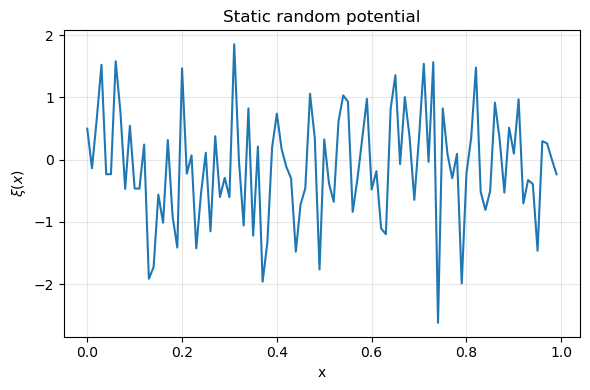

In [6]:
plt.figure(figsize=(6,4))

plt.plot(x, xi)

plt.xlabel("x")
plt.ylabel(r"$\xi(x)$")
plt.title("Static random potential")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### The Reaction Term

The reaction component of the equation is given by

$$
\xi(x)u(x,t).
$$

Using the initial condition $u_0(x)$, we visualize the product $\xi(x)u_0(x)$ to illustrate how the random potential modifies the solution before diffusion is applied.

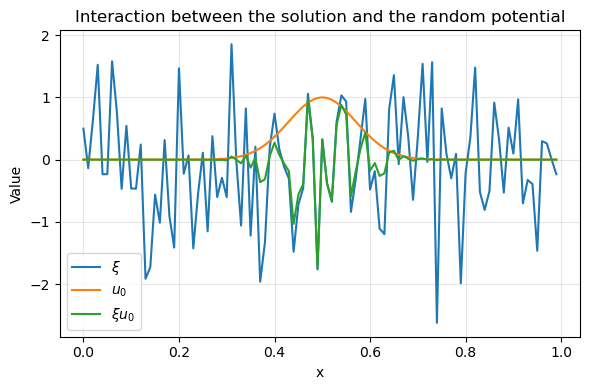

In [7]:
plt.figure(figsize=(6,4))

plt.plot(x, xi, label=r"$\xi$")
plt.plot(x, u0, label=r"$u_0$")
plt.plot(x, xi * u0, label=r"$\xi u_0$")

plt.xlabel("x")
plt.ylabel("Value")

plt.title("Interaction between the solution and the random potential")

plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Diffusion and Reaction

The Euler update consists of a diffusion term and a reaction term. Before performing an Euler update, we compute the diffusion and reaction contributions separately. Their sum determines the change in the solution over a single time step.

In [8]:
u = u0.copy()

diffusion = kappa * laplacian(u, h)
reaction = lambda_ * xi * u

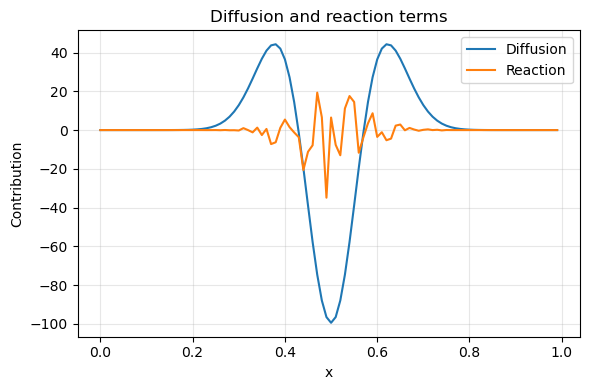

In [9]:
plt.figure(figsize=(6,4))

plt.plot(x, diffusion, label="Diffusion")
plt.plot(x, reaction, label="Reaction")

plt.xlabel("x")
plt.ylabel("Contribution")

plt.title("Diffusion and reaction terms")

plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### One Explicit Euler Step

Using these two contributions, we perform a single explicit Euler step. This provides a direct illustration of how the diffusion and reaction terms combine in the numerical update.

In [10]:
u_new = u + dt * (diffusion + reaction)

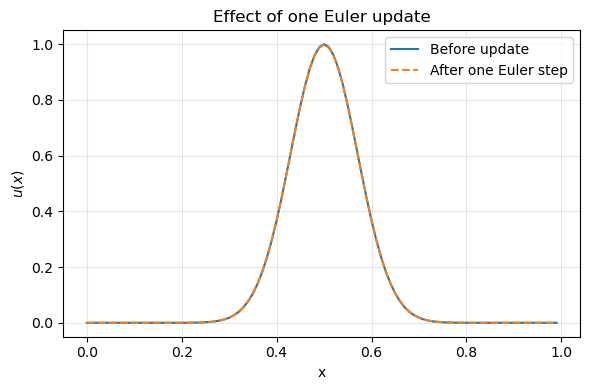

In [11]:
plt.figure(figsize=(6,4))

plt.plot(x, u, label="Before update")
plt.plot(x, u_new, '--', label="After one Euler step")

plt.xlabel("x")
plt.ylabel(r"$u(x)$")
plt.title("Effect of one Euler update")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### A Reusable Numerical Solver

We now implement a reusable solver for the one-dimensional parabolic Anderson model. The implementation follows the explicit Euler scheme derived above and records several intermediate snapshots for visualization.

In [12]:
def solve_static_pam(u0, xi, h, dt, num_steps, kappa=0.5, lambda_=1.0):
    """
    Solve the one-dimensional parabolic Anderson model
    with a static random potential using the explicit Euler method.
    """
    u = u0.copy()

    snapshots = [u.copy()]
    times = [0.0]

    for n in range(num_steps):
        diffusion = kappa * laplacian(u, h)
        reaction = lambda_ * xi * u

        u += dt * (diffusion + reaction)

        if (n + 1) % (num_steps // 4) == 0:
            snapshots.append(u.copy())
            times.append((n + 1) * dt)

    return u, snapshots, times

### Evolution of the Solution

The following figure shows the numerical solution at several time points. As the simulation progresses, the random potential produces increasingly uneven spatial growth, in contrast to the smoothing behavior observed for the heat equation.

In [13]:
u_pam, pam_snapshots, pam_times = solve_static_pam(
    u0,
    xi,
    h,
    dt,
    M,
    kappa=kappa,
    lambda_=lambda_,
)

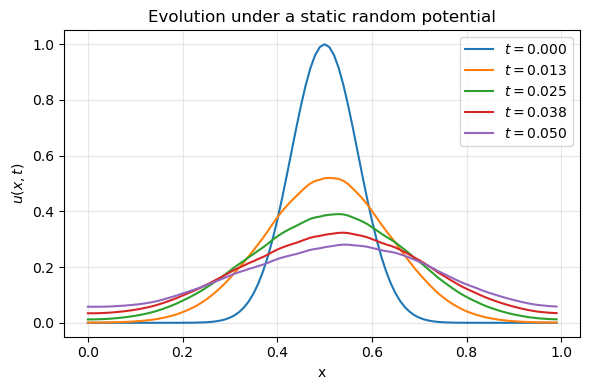

In [14]:
plt.figure(figsize=(6,4))

for u_snapshot, t in zip(pam_snapshots, pam_times):
    plt.plot(x, u_snapshot, label=f"$t={t:.3f}$")

plt.xlabel("x")
plt.ylabel(r"$u(x,t)$")
plt.title("Evolution under a static random potential")

plt.legend()

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Localization

Finally, we compare the numerical solution at the final time with the underlying random potential. Regions where the solution develops large peaks tend to align with favorable values of the potential, illustrating the localization phenomenon in the parabolic Anderson model.

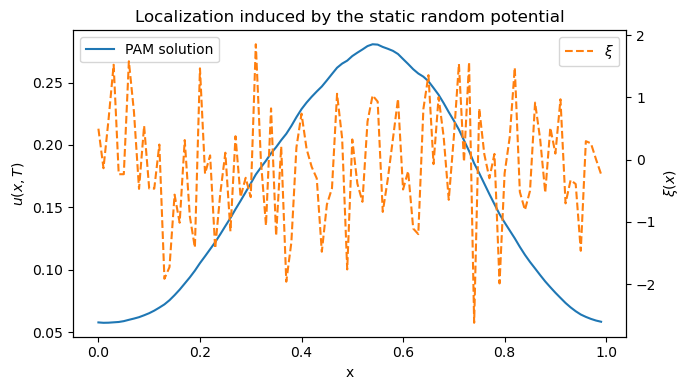

In [15]:
fig, ax1 = plt.subplots(figsize=(7,4))

ax1.plot(x, pam_snapshots[-1], color="C0", label="PAM solution")
ax1.set_xlabel("x")
ax1.set_ylabel(r"$u(x,T)$")

ax2 = ax1.twinx()
ax2.plot(x, xi, "--", color="C1", label=r"$\xi$")
ax2.set_ylabel(r"$\xi(x)$")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.title("Localization induced by the static random potential")

fig.tight_layout()
plt.show()

## Summary

In this notebook, we extended the heat equation by introducing a static random potential and implemented an explicit Euler solver for the one-dimensional parabolic Anderson model.



The numerical experiments demonstrate how the interaction between diffusion and a fixed random environment leads to localization. In the next notebook, we will replace the static potential with time-dependent random forcing to study stochastic heat equations driven by space-time noise.